In [ ]:
# Settings for figures
from enum import Enum

from pydantic import BaseModel

FIGURE_SIZE_ONE_COL = 3.5
FIGURE_SIZE_TWO_COL = 7.16
FONT_SIZE = 8

class Color(BaseModel):
    orange = "#fdb462"
    pink: str = "#decbe4"
    blue = "#b3cde3"
    green = "#ccebc5"
    light = "#DEF4FA"
    red: str = "#fbb4ae"
colors = Color()

In [1]:
import json
import os
import matplotlib.pyplot as plt
import numpy as np

# Server's Log

In [2]:
mode = "Expert"
offical_run = json.load(open(f"LSC24 Official {mode}.json"))

In [3]:
# Typing
TaskName = str
Target = str
TeamName = str

# Get tasks
template_tasks = offical_run["template"]["tasks"]
targets: dict[TaskName, list[Target]] = {}
queries: dict[TaskName, list[str]] = {}
durations: dict[TaskName, int] = {}
task_id_to_name: dict[str, TaskName] = {}

for i in range(len(template_tasks)):
    task_id_to_name[template_tasks[i]["id"]] = template_tasks[i]["name"]
    targets[template_tasks[i]["name"]] = []
    durations[template_tasks[i]["name"]] = template_tasks[i]["duration"]
    queries[template_tasks[i]["name"]] = [
        item["description"] for item in template_tasks[i]["hints"]
    ]
print(f"Found {len(template_tasks)} tasks")

teams = offical_run['template']['teams']
team_ids: dict[str, TeamName] = {item["id"]: item["name"] for item in teams}
print(f"Found {len(teams)} teams")

Found 16 tasks
Found 40 teams


In [4]:
from collections import defaultdict
from typing import Literal, Union

EXCLUDED_TEAMS: list[str] = ["Retrospect2", "LifeLens2", "CollaXRSearch2", "VitaChronicle2", "VitaChronicle3"]
TEAMS = [team_ids[team_id] for team_id in team_ids if team_ids[team_id] not in EXCLUDED_TEAMS]
TASK_TYPES = ["KIS", "QA", "AD"]

TaskType = Literal["KIS", "QA", "AD"]
def get_task_type(name: TaskName) -> TaskType:
    if "QA" in name:
        return "QA"
    elif "KIS" in name:
        return "KIS"
    return "AD"

def make_task_dicts(data_type):
    # deep copy obj to 3 keys: AD, QA, KIS
    return {task: defaultdict(data_type) for task in TASK_TYPES}

In [5]:
official_tasks = offical_run["tasks"]
print("Number of tasks: ", len(official_tasks))

submissions: dict[TaskName, list] = defaultdict(list)
task_names: list[TaskName] = []

for i in range(len(official_tasks)):
    name = task_id_to_name[official_tasks[i]["templateId"]]
    if name in queries:
        task_names.append(name)
        start_time = official_tasks[i]["started"]
        for item in official_tasks[i]["submissions"]:
            if item["teamName"] in EXCLUDED_TEAMS:
                continue
            assert (
                item["timestamp"] >= start_time
            ), f"Submission {item['timestamp']} is before start time {start_time}"

            for answer in item["answers"]:
                status = answer["status"]
                for ans in answer["answers"]:
                    if get_task_type(name) == "QA":
                        submissions[name].append(
                            (
                                item["teamName"],
                                status,
                                (item["timestamp"] - start_time) / 1000,
                                ans["text"],
                            )
                        )
                    else:
                        submissions[name].append(
                            (
                                item["teamName"],
                                status,
                                (item["timestamp"] - start_time) / 1000,
                                ans["item"]["name"],
                            )
                        )

Number of tasks:  16


## Correct/Incorrect

### Scoring

In [6]:
import math
from re import sub
import numpy as np

# Scores for each queries
max_point = 100
max_point_end = 50
penalty = 10
scores = {"QA": [], "AD": [], "KIS": []}
individual_scores = defaultdict(lambda: defaultdict(float))
task_per_types: dict[TaskType, list[TaskName]] = {
    "QA": [],
    "AD": [],
    "KIS": [],
}
recall_ad = defaultdict(list)
precision_ad = defaultdict(list)

for name, submission in submissions.items():
    task_type = get_task_type(name)

    correct = defaultdict(int)
    incorrect = defaultdict(int)
    correct_images = set()

    max_time = 180
    for team, status, time, image in submission:
        if status == "WRONG":
            incorrect[team] += 1
        elif status == "CORRECT":
            correct[team] += 1
            correct_images.add(image)
        else:
            print(f"Unknown status {status}")

    targets[name] = list(correct_images)
    print("-" * 20)
    print(f"Task {name} has {len(targets[name])} targets")
    print(queries[name][0])

    score = defaultdict(float)
    if task_type != "AD":
        submitted_correct = set()
        for team, status, time, image in submission:
            if team in submitted_correct:
                continue
            if image in correct_images:
                submitted_correct.add(team)
                score[team] += max_point_end + (max_point - max_point_end) * (
                    1 - time / durations[name]
                )
            elif status == "WRONG":
                score[team] -= penalty
        for team in TEAMS:
            score[team] = max(0, score[team])
    else:
        for team in TEAMS:
            if correct[team] == 0:
                score[team] = 0
                recall_ad[team].append(0)
                precision_ad[team].append(0)
            else:
                score[team] = (
                    correct[team]
                    * max_point
                    / (correct[team] + incorrect[team] / 2)
                    * correct[team]
                    / len(correct_images)
                )
                recall_ad[team].append(correct[team] / len(correct_images))
                precision_ad[team].append(
                    correct[team] / (correct[team] + incorrect[team])
                )
    
    individual_scores[name] = score
    scores[task_type].append(score)
    task_per_types[task_type].append(name)

precision_ad = {team: np.mean(precision_ad[team]) for team in TEAMS}
recall_ad = {team: np.mean(recall_ad[team]) for team in TEAMS}

Unknown status UNDECIDABLE
Unknown status UNDECIDABLE
--------------------
Task LSC24-KISJ02 has 5 targets
Japanese pens are the best, so I bought some on that wet evening.
Unknown status UNDECIDABLE
Unknown status UNDECIDABLE
Unknown status UNDECIDABLE
Unknown status UNDECIDABLE
Unknown status UNDECIDABLE
--------------------
Task LSC24-AD01 has 12 targets
At the start of covid-time, my building in Dublin City University was locked. Find examples of when I was waiting for a security guard to let me into my office building.
--------------------
Task LSC24-QA01 has 1 targets
A,B,C,D,E,F, Y or Z? I can’t recall which zone of the car park in the airport I parked in when I was going to France in 2019.

--------------------
Task LSC24-KISJ03 has 1 targets
I was sent to the back door, but it was closed.
Unknown status UNDECIDABLE
Unknown status INDETERMINATE
--------------------
Task LSC24-AD02 has 21 targets
I have a blue noticeboard in my office with various lifelogging devices pinned to i

In [7]:
# Export to json real tasks and their targets
data = []
for i in range(len(task_names)):
    data.append(
        {
            "name": task_names[i],
            "queries": queries[task_names[i]],
            "targets": targets[task_names[i]],
            "submissions": submissions[task_names[i]],
        }
    )
json.dump(data, open(f"LSC24_{mode}_tasks.json", "w"), indent=2)

In [8]:
from collections import defaultdict
import numpy as np
correct_counts = make_task_dicts(int)
incorrect_counts = make_task_dicts(int)
total_counts = make_task_dicts(int)
time_till_correct = defaultdict(lambda: defaultdict(lambda: np.inf))
time_till_correct_full = defaultdict(lambda: defaultdict(lambda: 300))
top_3 = make_task_dicts(int)

for team in TEAMS:
    for name in task_names:
        time_till_correct_full[team][name] = durations[name]

for name in submissions:
    correct_time = 0
    task_type = get_task_type(name) 
    for team, status, time, image in submissions[name]:
        if status == "CORRECT" or image in targets[name]:
            correct_counts[task_type][team] += 1

            time = min(time, durations[name])
            time_till_correct[team][name] = min(time_till_correct[team][name], time)
            time_till_correct_full[team][name] = min(time_till_correct_full[team][name], time)
            correct_time += 1
            if correct_time <= 3:
                top_3[task_type][team] += 1

        elif status == "WRONG":
            incorrect_counts[task_type][team] += 1

        total_counts[task_type][team] += 1

In [9]:
from collections import defaultdict, OrderedDict

normalize_scores = {"QA": {}, "AD": {}, "KIS": {}, "SUM": defaultdict(float)}
for task_type in TASK_TYPES:
    cum_scores = defaultdict(float)
    for score in scores[task_type]:  # iterate over all tasks in this task_type
        for team in score:
            cum_scores[team] += score[team]

    max_score = max(cum_scores.values())
    for team in cum_scores:
        normalize_scores[task_type][team] = round(cum_scores[team] / max_score * 100)
        normalize_scores["SUM"][team] += normalize_scores[task_type][team]

# sort TEAMS by normalize_scores
TEAMS = sorted(TEAMS, key=lambda team: normalize_scores["SUM"][team], reverse=True)
for task_type in TASK_TYPES:
    # sort dict by TEAMS
    normalize_scores[task_type] = OrderedDict(
        sorted(normalize_scores[task_type].items(), key=lambda x: TEAMS.index(x[0]))
    )
print([(team, normalize_scores["SUM"][team]) for team in TEAMS])

[('LIFEXPLORE1', 261.0), ('SnapSeek1', 253.0), ('LIFEXPLORE2', 252.0), ('VISIONE1', 248.0), ('Libro1', 239.0), ('Exquisitor', 234.0), ('PraK1', 229.0), ('VISIONE3', 218.0), ('Libro2', 208.0), ('LIFEXPLORE3', 208.0), ('SnapSeek2', 189.0), ('SnapSeek4', 186.0), ('SnapSeek5', 185.0), ('EAGLE1', 185.0), ('MEMORIA', 181.0), ('Retrospect1', 179.0), ('PraK2', 179.0), ('LifeInsight', 177.0), ('VitaChronicle1', 177.0), ('CollaXRSearch1', 174.0), ('vitrivr-VR', 173.0), ('MemoriEase', 173.0), ('Libro3', 165.0), ('LifeSeeker1', 161.0), ('SnapSeek3', 160.0), ('VISIONE2', 158.0), ('Memento', 157.0), ('EAGLE2', 155.0), ('LifeLens1', 139.0), ('Lifegraph', 138.0), ('vitrivr', 134.0), ('Voxento', 129.0), ('MyEachtra', 121.0), ('PraK3', 119.0), ('LifeSeeker2', 78.0)]


In [10]:
# Remove teams with 0 score
TEAMS = [team for team in TEAMS if normalize_scores["SUM"][team] > 0]
# Remove teams with 0 correct counts
TEAMS: list[str] = [team for team in TEAMS if sum(correct_counts[task_type][team] for task_type in TASK_TYPES) > 0]

# GRAPHS

In [11]:
import pandas as pd
import seaborn as sns

# Each row is a task corresponding to a team
# Columns: team, task, task_type, score, incorrect, correct, time_till_correct
detailed_df = pd.DataFrame(
    columns=[
        "team",
        "task",
        "task_type",
        "score",
        "incorrect",
        "correct",
        "time_till_correct",
    ]
)
import math
from re import sub
import numpy as np

# Scores for each queries
max_point = 100
max_point_end = 50
penalty = 10
scores = {"QA": [], "AD": [], "KIS": []}
task_per_types: dict[TaskType, list[TaskName]] = {
    "QA": [],
    "AD": [],
    "KIS": [],
}

for name, submission in submissions.items():
    task_type = get_task_type(name)

    correct = defaultdict(int)
    incorrect = defaultdict(int)
    correct_images = set()

    max_time = 180
    for team, status, time, image in submission:
        if status == "WRONG":
            incorrect[team] += 1
        elif status == "CORRECT":
            correct[team] += 1
            correct_images.add(image)
        else:
            print(f"Unknown status {status}")

    targets[name] = list(correct_images)
    print("-" * 20)
    print(f"Task {name} has {len(targets[name])} targets")
    print(queries[name][0])

    score = defaultdict(float)
    if task_type != "AD":
        submitted_correct = set()
        for team, status, time, image in submission:
            if team in submitted_correct:
                continue
            if image in correct_images:
                submitted_correct.add(team)
                score[team] += max_point_end + (max_point - max_point_end) * (
                    1 - time / durations[name]
                )
            elif status == "WRONG":
                score[team] -= penalty
        for team in TEAMS:
            score[team] = max(0, score[team])
    else:
        for team in TEAMS:
            if correct[team] == 0:
                score[team] = 0
            else:
                score[team] = (
                    correct[team]
                    * max_point
                    / (correct[team] + incorrect[team] / 2)
                    * correct[team]
                    / len(correct_images)
                )
    scores[task_type].append(score)
    task_per_types[task_type].append(name)

    for team in TEAMS:
        detailed_df = pd.concat([detailed_df, pd.DataFrame([  # Wrap the dictionary in a list
            {
                "team": team,
                "task": name,
                "task_type": task_type,
                "score": score[team],
                "incorrect": incorrect[team],
                "correct": correct[team],
                "time_till_correct": time_till_correct[team][name],
            }])], ignore_index=True)
detailed_df.to_csv("detailed_scores.csv")

Unknown status UNDECIDABLE
Unknown status UNDECIDABLE
--------------------
Task LSC24-KISJ02 has 5 targets
Japanese pens are the best, so I bought some on that wet evening.
Unknown status UNDECIDABLE
Unknown status UNDECIDABLE
Unknown status UNDECIDABLE
Unknown status UNDECIDABLE
Unknown status UNDECIDABLE
--------------------
Task LSC24-AD01 has 12 targets
At the start of covid-time, my building in Dublin City University was locked. Find examples of when I was waiting for a security guard to let me into my office building.
--------------------
Task LSC24-QA01 has 1 targets
A,B,C,D,E,F, Y or Z? I can’t recall which zone of the car park in the airport I parked in when I was going to France in 2019.

--------------------
Task LSC24-KISJ03 has 1 targets
I was sent to the back door, but it was closed.
Unknown status UNDECIDABLE
Unknown status INDETERMINATE
--------------------
Task LSC24-AD02 has 21 targets
I have a blue noticeboard in my office with various lifelogging devices pinned to i

In [12]:
import pandas as pd
import seaborn as sns


df = None
for task_type in TASK_TYPES:
    data = {
        "team": TEAMS,
        "task": [f"{task_type}" for team in TEAMS],
        f"correct": [correct_counts[task_type][team] for team in TEAMS],
        f"incorrect": [incorrect_counts[task_type][team] for team in TEAMS],
        # f"cum_score_{task}": [cum_scores[task][team] for team in TEAMS],
        f"norm_score": [normalize_scores[task_type][team] for team in TEAMS],
    }
    if task_type != "AD":
        data.update({
            f"top_3": [top_3[task_type][team] for team in TEAMS],
            f"precision": [correct_counts[task_type][team]/total_counts[task_type][team] if total_counts[task_type][team] > 0 else 0 for team in TEAMS],
            f"recall": [correct_counts[task_type][team]/len(scores[task_type]) for team in TEAMS]})
    else:
        data["recall"] = [recall_ad[team] for team in TEAMS]
        data["precision"] = [precision_ad[team] for team in TEAMS]
    for i in time_till_correct["MyEachtra"]:
        data[f"time_correct_{i}"] = [time_till_correct[team][i] for team in TEAMS]
    for i in time_till_correct_full["MyEachtra"]:
        data[f"time_correct_full_{i}"] = [time_till_correct_full[team][i] for team in TEAMS]
    if df is None:
        df = pd.DataFrame(data=data)
    else:
        df = pd.concat([df, pd.DataFrame(data=data)], axis=0)   

assert df is not None, "df is None"
# Remove teams with 0 scores on all tasks
df = df[df["norm_score"] > 0]
df

,team,task,correct,incorrect,norm_score,top_3,precision,recall,time_correct_LSC24-KISJ03,time_correct_LSC24-QA02,...,time_correct_full_LSC24-KIS04,time_correct_full_LSC24-KISJ04,time_correct_full_LSC24-AD03,time_correct_full_LSC24-QA03,time_correct_full_LSC24-KISJ05,time_correct_full_LSC24-AD04,time_correct_full_LSC24-QA04,time_correct_full_LSC24-KISJ06,time_correct_full_LSC24-AD05,time_correct_full_LSC24-QA05
0,LIFEXPLORE1,KIS,5,2,95,1.0,0.625000,0.833333,187.391,38.723,...,300,7.694,23.254,17.331,93.432,52.229,49.273,77.969,19.924,70.655
1,SnapSeek1,KIS,6,0,95,0.0,1.000000,1.000000,177.263,52.759,...,300,28.804,67.105,40.222,132.188,34.799,300.000,162.683,23.329,300.000
2,LIFEXPLORE2,KIS,5,0,96,1.0,1.000000,0.833333,232.345,26.349,...,300,21.566,78.444,17.492,80.617,37.286,181.573,32.578,19.373,41.260
3,VISIONE1,KIS,4,4,72,0.0,0.500000,0.666667,185.520,62.068,...,300,81.538,32.913,25.509,123.500,29.759,122.021,300.000,17.900,227.492
4,Libro1,KIS,5,1,100,0.0,0.833333,0.833333,201.286,62.313,...,300,17.533,54.071,23.983,79.473,49.182,148.371,64.200,45.716,45.040
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30,vitrivr,AD,72,3,24,NaN,0.914286,0.106899,196.502,66.242,...,300,66.413,93.976,63.970,131.121,48.417,300.000,300.000,30.281,143.821
31,Voxento,AD,87,2,17,NaN,0.654805,0.084402,inf,78.300,...,300,45.110,32.480,300.000,297.728,82.488,73.140,300.000,22.237,76.590
32,MyEachtra,AD,94,16,11,NaN,0.309691,0.060958,190.313,58.117,...,300,300.000,175.523,300.000,125.141,168.235,70.408,143.937,23.312,68.627
33,PraK3,AD,26,13,26,NaN,0.675556,0.125731,209.450,inf,...,300,300.000,60.515,33.689,99.802,180.000,300.000,300.000,46.176,75.218


In [13]:
df.to_csv(f"{mode}_scores.csv", index=False)

In [14]:
assert df is not None, "df is None"

import matplotlib.pyplot as plt
from regex import D

colors = Color()

sns.set_style("white")
plt.rcParams.update(
    {
        "font.family": "serif",  # Or 'DejaVu Serif', 'Times New Roman'
        "font.size": 10,
        "pdf.fonttype": 42,  # Use TrueType fonts in PDF (not Type 3)
        "ps.fonttype": 42,
    }
)
all_score = (
    df.groupby(["team", "task"])
    .sum()
    .reset_index()
    .pivot(index="team", columns="task", values="norm_score")
)

# Replace NaN with empty string
all_score = all_score.fillna(0)
# Convert float to int
all_score = all_score.astype(int)
all_score = all_score.reindex(columns=TASK_TYPES)

# sort by the sum of scores
sum_score = all_score.sum(axis=1)
all_score = all_score.loc[sum_score.sort_values(ascending=True).index]

fig = all_score.plot.barh(
    figsize=(FIGURE_SIZE_ONE_COL * 2, FIGURE_SIZE_ONE_COL * 3.6),
    rot=0,
    stacked=True,
    title="Scores in all tasks in LSC'24",
    width=0.8,
    color=sns.color_palette("pastel", n_colors=3),
    legend=True,
)

fig.bar_label(fig.containers[0], labels=all_score["KIS"], label_type="center")  # type: ignore
fig.bar_label(fig.containers[1], labels=all_score["QA"], label_type="center")  # type: ignore
fig.bar_label(fig.containers[2], labels=all_score["AD"], label_type="center")  # type: ignore

# Highlighting LifeXplore and vitrivr (for example)
# fig.axes.get_yticklabels()[-1].set_fontweight("bold")
# fig.axes.get_yticklabels()[-16].set_fontweight("bold")

plt.xlabel("Scores")
plt.ylabel("Teams")
plt.title(f"Scores in all {mode} tasks in LSC'24", fontweight="bold", fontsize=16, y=1.02)
plt.legend(title="Task type")
plt.savefig(f"{mode}_overall_24.pdf", format="pdf", bbox_inches="tight", dpi=300)

NameError: name 'Color' is not defined

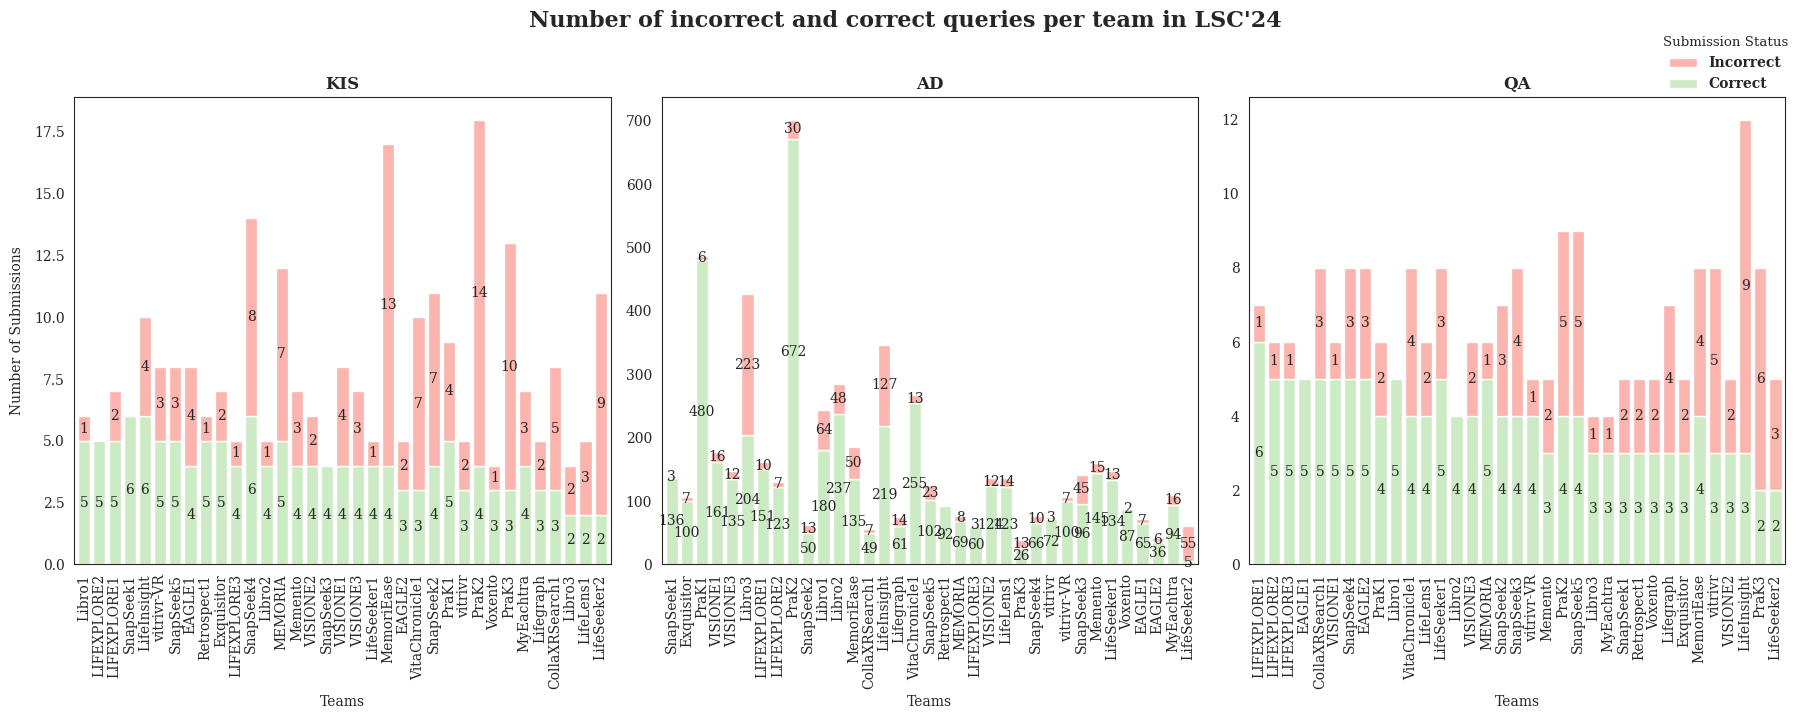

In [ ]:
# !pip install -U matplotlib
import matplotlib.pyplot as plt
sns.set_style("white")

plt.rcParams.update(
    {
        "font.family": "serif",  # Or 'DejaVu Serif', 'Times New Roman'
        "font.size": 10,
        "pdf.fonttype": 42,  # Use TrueType fonts in PDF (not Type 3)
        "ps.fonttype": 42,
        'figure.figsize': (FIGURE_SIZE_TWO_COL * 2.5, FIGURE_SIZE_ONE_COL * 2)
    }
)
# Create subplots
fig, axes = plt.subplots(1, len(["KIS", "AD", "QA"]))
# Plot data for each TASK
for i, TASK in enumerate(["KIS", "AD", "QA"]):
    filtered = df[df["task"] == TASK]
    filtered = filtered.sort_values("norm_score", ascending=False)
    ax = filtered[["team", "correct", "incorrect"]].plot(x='team', kind='bar', stacked=True, width=0.8, color=[colors.green, colors.red], ax=axes[i])
    ax.bar_label(ax.containers[0], labels=filtered["correct"], label_type='center')
    ax.bar_label(ax.containers[1], labels=["" if x == 0 else x for x in filtered["incorrect"]], label_type='center')
    
    ax.set_xlabel("Teams")
    # ax.set_ylabel("Number of {} queries".format(TASK), fontweight='bold')
    ax.set_xticklabels(filtered["team"])
    if i == 0:
        ax.text(-0.12, 0.5, "Number of Submissions", va='center', rotation='vertical', transform=ax.transAxes)


    # Turn off legend
    ax.legend().set_visible(False)

    # Title of the subplot
    ax.set_title(f"{TASK}", fontweight='bold')

# Create a single legend for all subplots
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles[::-1], ["Incorrect", "Correct"], loc='upper right', bbox_to_anchor=(1, 1), frameon=False, prop={'weight': 'bold'},
              title="Submission Status", title_fontsize=FONT_SIZE * 1.2)
plt.subplots_adjust(top=0.9)  # Adjust the top margin for the suptitle
fig.suptitle("Number of incorrect and correct queries per team in LSC'24", fontweight='bold', fontsize=16, y=1.02)
plt.tight_layout()
# plt.savefig("incorrect_correct.eps", format="eps", bbox_inches='tight', dpi=1200)
plt.savefig("incorrect_correct_24.pdf", format="pdf", bbox_inches='tight', dpi=300)

/tmp/ipykernel_1721599/2857485427.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered["precision"] = filtered["precision"] * 100
/tmp/ipykernel_1721599/2857485427.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered["recall"] = filtered["recall"] * 100


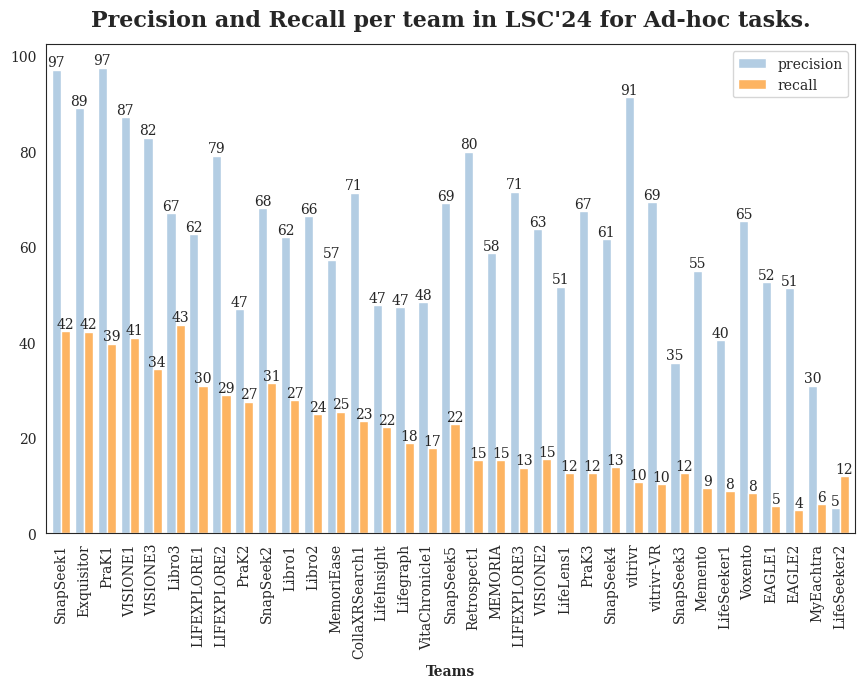

In [ ]:
# !pip install -U matplotlib
assert df is not None, "df is None"
import matplotlib.pyplot as plt

sns.set_style("white")
plt.rcParams.update(
    {
        "font.family": "serif",  # Or 'DejaVu Serif', 'Times New Roman'
        "font.size": 10,
        "pdf.fonttype": 42,  # Use TrueType fonts in PDF (not Type 3)
        "ps.fonttype": 42,
        "figure.figsize": (FIGURE_SIZE_ONE_COL * 2.5, FIGURE_SIZE_ONE_COL * 2),
    }
)
# Plot data for each TASK
filtered = df[df["task"] == "AD"]
filtered["precision"] = filtered["precision"] * 100
filtered["recall"] = filtered["recall"] * 100
filtered = filtered.sort_values("norm_score", ascending=False)

# Create plot
fig = filtered[["team", "precision", "recall"]].plot(x='team', kind='bar', width=0.8, color=[colors.blue, colors.orange])

# Add labels to the bars
fig.bar_label(fig.containers[0], labels=[int(x) for x in filtered["precision"]], label_type='edge') # type: ignore
fig.bar_label(fig.containers[1], labels=["" if x == 0 else int(x) for x in filtered["recall"]], label_type='edge') # type: ignore

plt.xlabel("Teams", fontweight='bold')
# fig.axes.get_xticklabels()[0].set_fontweight("bold")
# fig.axes.get_xticklabels()[5].set_fontweight("bold")

plt.subplots_adjust(top=0.9)  # Adjust the top margin for the suptitle
plt.title("Precision and Recall per team in LSC'24 for Ad-hoc tasks.", fontweight='bold', fontsize=16, y=1.02)

# Add spacing between subplots
plt.tight_layout()
plt.savefig("precision-recall_24.pdf", format="pdf", bbox_inches='tight', dpi=300)

/tmp/ipykernel_1721599/1228880504.py:44: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(filtered["team"])
/tmp/ipykernel_1721599/1228880504.py:44: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(filtered["team"])
/tmp/ipykernel_1721599/1228880504.py:44: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(filtered["team"])


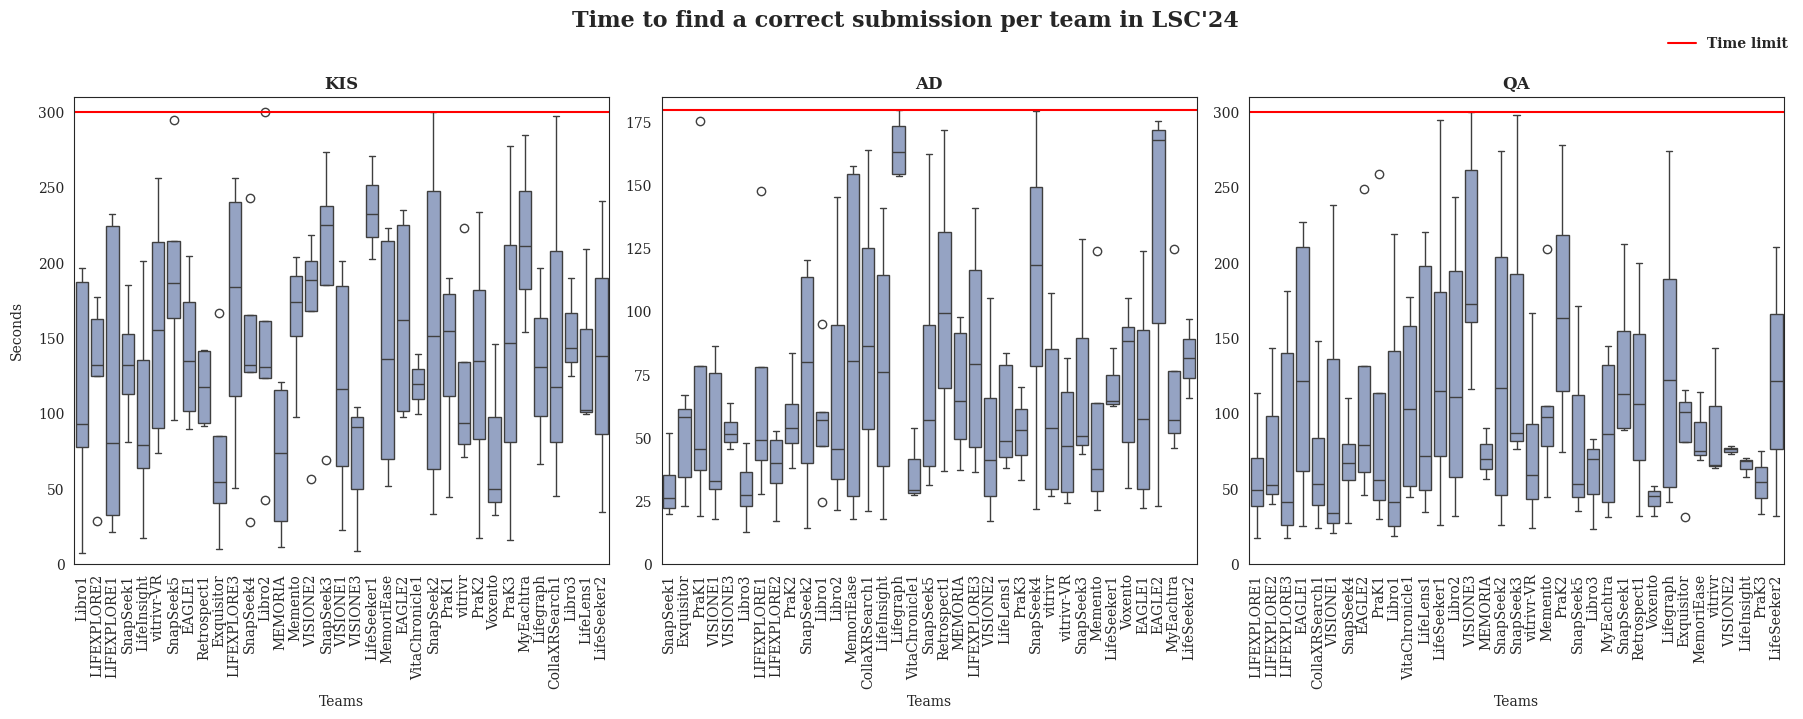

In [ ]:
# !pip install -U matplotlib
assert df is not None, "df is None"
import matplotlib.pyplot as plt
sns.set_style("white")
SCALE = 2
# plt.rcParams.update({'font.size': FONT_SIZE, 'figure.figsize': (FIGURE_SIZE_TWO_COL * SCALE, FIGURE_SIZE_ONE_COL * SCALE)})
plt.rcParams.update(
    {
        "font.family": "serif",  # Or 'DejaVu Serif', 'Times New Roman'
        "font.size": 10,
        "pdf.fonttype": 42,  # Use TrueType fonts in PDF (not Type 3)
        "ps.fonttype": 42,
        "figure.figsize": (FIGURE_SIZE_TWO_COL * 2.5, FIGURE_SIZE_ONE_COL * 2),
    }
)

# Create subplots
fig, axes = plt.subplots(1, len(TASK_TYPES))
limits = {"KIS": 300, "QA": 300, "AD": 180}

# Plot data for each TASK
for i, TASK in enumerate(TASK_TYPES):
    filtered = df[df["task"] == TASK]
    filtered = filtered.sort_values("norm_score", ascending=False)
    tasks = [f"time_correct_{i}" for i in task_names if get_task_type(i) == TASK]
    tasks = [task for task in tasks if task in filtered.columns]

    # ax = filtered[tasks].T.plot(kind='box',
    #     showmeans=False, showfliers=True,
    #     boxprops=dict(facecolor="#8da0cb", color="#8da0cb", linewidth=1),
    #     medianprops=dict(color="black", linewidth=1),
    #     capprops=dict(color="black", linewidth=1),
    #     flierprops=dict(marker='o', markersize=3, color="#8da0cb"),
    #     patch_artist=True,
    #     ax=axes[i])

    ax = sns.boxplot(data=filtered[tasks].T, ax=axes[i], color="#8da0cb", showmeans=False, showfliers=True, linewidth=1)
    
    # ax.bar_label(ax.containers[0], labels=filtered["precision"], label_type='center')
    # ax.bar_label(ax.containers[1], labels=["" if x == 0 else x for x in filtered["recall"]], label_type='center')
    
    ax.set_xlabel("Teams")
    # ax.set_ylabel("Number of {} queries".format(TASK), fontweight='bold')
    ax.set_xticklabels(filtered["team"])
    if i == 0:
        ax.text(-0.12, 0.5, "Seconds", va='center', rotation='vertical', transform=ax.transAxes)

    # set rotation of x-axis labels
    ax.tick_params(axis='x', rotation=90)
    
    # add a horizontal line for the limit (with label)
    ax.axhline(y=limits[TASK], color='r', linestyle='-', label=f"Time limit: {limits[TASK]}s")

    if TASK == "KIS":
        ax.set_ylim(0, 310)
    elif TASK == "QA":
        ax.set_ylim(0, 310)
    else:
        ax.set_ylim(0, 185)
    
    # Turn off legend
    ax.legend().set_visible(False)

    # Title of the subplot
    ax.set_title(f"{TASK}", fontweight='bold')


# Create a single legend for all subplots
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, ["Time limit"], loc='upper right', bbox_to_anchor=(1, 1), frameon=False, prop={'weight': 'bold'})
plt.subplots_adjust(top=0.9)  # Adjust the top margin for the suptitle
fig.suptitle("Time to find a correct submission per team in LSC'24", fontweight='bold', fontsize=16, y=1.02)

# Add spacing between subplots
plt.tight_layout()
plt.savefig("time_24.pdf", format="pdf", bbox_inches='tight', dpi=300)

In [ ]:
from numpy import median


filtered = df[df["task"] == "KIS"]
tasks = [f"time_correct_{i}" for i in task_names if get_task_type(i) == "KIS"]
tasks = [task for task in tasks if task in filtered.columns]
time = filtered[tasks]
# change inf to na
time = time.replace([np.inf, -np.inf], np.nan)
# get all the values
time = time.values.flatten()
time = time[~np.isnan(time)]
# get mean and std
mean_time = np.mean(time)
std_time = np.std(time)
median = np.median(time)
print(f"KIS: mean time: {mean_time}, std: {std_time}, median: {median}")

KIS: mean time: 138.6906788321168, std: 76.01920127244979, median: 132.188


In [ ]:
# boxplot for each task
from cv2 import mean
from httpx import patch
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import matplotlib.gridspec as gridspec


SCALE = 2
sns.set_style("white")
plt.rcParams.update(
    {
        "font.family": "serif",  # Or 'DejaVu Serif', 'Times New Roman'
        "font.size": 10,
        "pdf.fonttype": 42,  # Use TrueType fonts in PDF (not Type 3)
        "ps.fonttype": 42,
    }
)
TASK_TYPES = ["KIS", "AD", "QA"]

# Create subplots
task_names = sorted(task_names, key=lambda x: TASK_TYPES.index(get_task_type(x)))
task_scores = {task: [] for task in task_names}
for team in TEAMS:
    for task in task_names:
        task_scores[task].append(individual_scores[task][team])

task_df = pd.DataFrame(data=task_scores)
grid_spec = gridspec.GridSpec(
    3, 2, width_ratios=[4, 1], height_ratios=[0.1, 7, 1], hspace=0, wspace=0
)

fig = plt.figure(figsize=(FIGURE_SIZE_TWO_COL * 2, FIGURE_SIZE_TWO_COL * 2.5))

# Heatmap first
ax = fig.add_subplot(grid_spec[1, 0])
sns.heatmap(task_df, cmap="YlGnBu", annot=True, fmt=".0f", ax=ax, cbar=False)
# off the x-axis
ax.set_xticklabels("")
ax.axvline(x=6, color="black", linestyle="-")
ax.axvline(x=11, color="black", linestyle="-")

# Set y-axis label to TEAMS
ax.set_yticklabels(TEAMS, fontweight="bold")
# Rotate y-axis labels
ax.tick_params(axis="y", rotation=0)

# Boxplot for each TASK (at the bottom)
ax = fig.add_subplot(grid_spec[2, 0])
meancolor = "#225ea8"
color = "#41b6c4"
sns.boxplot(
    data=task_df,
    ax=ax,
    orient="v",
    color=color,
    gap=0.7,
    showfliers=True,
    showmeans=True,
    fill=False,
    dodge=True,
    meanprops={"markerfacecolor": meancolor, "markeredgecolor": meancolor},
)
# rotate x-axis labels
ax.tick_params(axis="x", rotation=90)
# remove box
for i in ax.spines.values():
    i.set_visible(False)

# draw a line at the 5th xtick
ax.axvline(x=5.5, color="black", linestyle="-")
ax.axvline(x=10.5, color="black", linestyle="-")
# remove y-axis ticks
ax.set_yticklabels("")

# Plot data for each TEAM (on the right)
ax = fig.add_subplot(grid_spec[1, 1])
sns.boxplot(
    data=task_df.T,
    showfliers=True,
    showmeans=True,
    ax=ax,
    orient="h",
    gap=0.5,
    color=color,
    fill=False,
    meanprops={"markerfacecolor": meancolor, "markeredgecolor": meancolor},
)
ax.set_yticklabels("")
for i in ax.spines.values():
    i.set_visible(False)
ax.set_xticklabels("")

# Add space for sub-titles
plt.subplots_adjust(top=0.9)
plt.suptitle(
    "Scores per team in LSC'24", fontweight="bold", fontsize=16
)

plt.tight_layout()
plt.savefig(f"{mode}_task_team_score_24.pdf", format="pdf", bbox_inches="tight")

In [ ]:
task_df.mean()

LSC24-KIS04      0.000000
LSC24-KISJ02    52.586710
LSC24-KISJ03    42.712724
LSC24-KISJ04    70.526576
LSC24-KISJ05    69.638348
LSC24-KISJ06    52.316076
LSC24-AD01      22.869398
LSC24-AD02      19.860664
LSC24-AD03       9.231732
LSC24-AD04      23.125600
LSC24-AD05      16.805327
LSC24-QA01      32.546790
LSC24-QA02      78.608943
LSC24-QA03      82.239457
LSC24-QA04      40.345410
LSC24-QA05      72.533386
dtype: float64

In [ ]:
task_df.median()

LSC24-KIS04      0.000000
LSC24-KISJ02    64.814000
LSC24-KISJ03    58.281167
LSC24-KISJ04    88.931167
LSC24-KISJ05    78.146500
LSC24-KISJ06    68.315667
LSC24-AD01       6.818182
LSC24-AD02      10.714286
LSC24-AD03       8.333333
LSC24-AD04      14.285714
LSC24-AD05      12.722463
LSC24-QA01       0.000000
LSC24-QA02      88.427667
LSC24-QA03      94.385167
LSC24-QA04      46.352667
LSC24-QA05      85.451000
dtype: float64